<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
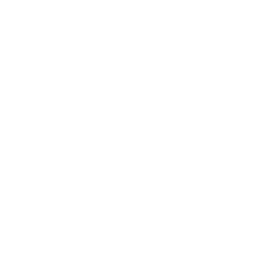
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Equipment Reliability Analysis by Generation</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Reliability Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Περίληψη για τη Διοίκηση

Αυτή η ανάλυση χρησιμοποιεί την **PROC LIFETEST** για να συγκρίνει την
αξιοπιστία πεδίου τριών διαδοχικών γενιών σχεδιασμού μηχανών CNC
φρεζαρίσματος. Ξεκινώντας από ένα στιγμιότυπο 100 μηχανών εργοστασίου
(75 αστοχίες, 25 μονάδες ακόμη σε λειτουργία και επομένως δεξιά-λογοκριμένες),
εκτιμά την καμπύλη επιβίωσης Kaplan-Meier για κάθε γενιά και ελέγχει αν οι
καμπύλες διαφέρουν τόσο με το στατιστικό log-rank όσο και με το
Gehan-Breslow-Wilcoxon.

Τα δεδομένα λένε μια σαφή ιστορία ενός βήματος. Οι αρχικές μηχανές
**ΓΕΝΙΑ_1** είναι αισθητά λιγότερο αξιόπιστες από τους δύο νεότερους
σχεδιασμούς: ο διάμεσος χρόνος ζωής υπηρεσίας τους είναι **5.282 ώρες
λειτουργίας**, περίπου το ένα τρίτο της **ΓΕΝΙΑ_2** (**16.430 ώρες**) και
της **ΓΕΝΙΑ_3** (**13.512 ώρες**). Και οι δύο έλεγχοι ομοιογένειας
απορρίπτουν την ισότητα των τριών καμπυλών επιβίωσης -- log-rank
χι-τετράγωνο **12,92** (2 βαθμοί ελευθερίας, *p* = **0,0016**) και
Wilcoxon **11,88** (2 βαθμοί ελευθερίας, *p* = **0,0026**). Στις 10.000
ώρες λειτουργίας μόνο το **24%** των μηχανών ΓΕΝΙΑ_1 αναμένεται να είναι
ακόμη σε λειτουργία, έναντι **64%** για τη ΓΕΝΙΑ_2 και **57%** για τη
ΓΕΝΙΑ_3.

Η βελτίωση **δεν** είναι μια ομαλή, γενιά-προς-γενιά κέρδιση: η ΓΕΝΙΑ_2 και
η ΓΕΝΙΑ_3 επιβιώνουν με πολύ παρόμοιους ρυθμούς και είναι στατιστικά
μη διακριτές μεταξύ τους σε αυτό το μέγεθος δείγματος. Το αξιοποιήσιμο
εύρημα είναι η αλλαγή βήματος από τη ΓΕΝΙΑ_1 στον ανασχεδιασμένο στόλο,
που θα πρέπει να καθοδηγήσει τις προτεραιότητες αντικατάστασης και
προληπτικής συντήρησης προς τις υπόλοιπες μονάδες ΓΕΝΙΑ_1.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|---------|
| WORK.EQUIPMENT_LIFE | Μία γραμμή ανά μηχανή CNC: γενιά σχεδιασμού, εργοστάσιο, έτος εγκατάστασης, ώρες λειτουργίας κατά την αστοχία ή την τελευταία παρατήρηση, και δείκτης αστοχίας / λογοκρισίας | 100 |

Το σύνολο δεδομένων είναι συνθετικό και δημιουργείται στο επόμενο κελί με
σταθερό σπόρο (`streaminit(42)`) ώστε η ανάλυση να είναι πλήρως
αναπαραγώγιμη. Ο χρόνος ζωής υπηρεσίας προέρχεται από ένα εκθετικό
μοντέλο ανά γενιά, και οι νεότερες γενιές φέρουν υψηλότερο ποσοστό
λογοκρισίας επειδή έχουν περάσει λιγότερα ημερολογιακά έτη σε λειτουργία.

---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικού συνόλου δεδομένων αξιοπιστίας εξοπλισμού.

   Κάθε γραμμή είναι μία μηχανή CNC φρεζαρίσματος. Το OPERATING_HOURS
   είναι ο χρόνος υπηρεσίας στον οποίο η μηχανή είτε αστόχησε
   (FAILURE_EVENT=1) είτε παρατηρήθηκε τελευταία φορά ακόμη σε
   λειτουργία (FAILURE_EVENT=0, δεξιά-λογοκριμένη). Τρεις γενιές
   σχεδιασμού λαμβάνουν προοδευτικά μεγαλύτερους μέσους χρόνους ζωής
   ώστε να μπορούμε να ρωτήσουμε αν οι ανασχεδιασμοί πράγματι
   βελτίωσαν την αξιοπιστία πεδίου.

   Αυτό το μη αδειοδοτημένο περιβάλλον περιορίζει την έξοδο σε 100
   παρατηρήσεις, οπότε μοντελοποιούμε ακριβώς 100 μηχανές -- ένα
   ρεαλιστικό στιγμιότυπο στόλου ενός εργοστασίου.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.equipment_life;
    CALL streaminit(42);
    LENGTH generation $14 plant_location $30 failure_mode $10;
    ARRAY fail_scale[3]       _temporary_ (8000 12000 16000);
    ΕΠΑΝΑΛΗΨΗ equip_seq = 1 ΕΩΣ 100;
        equipment_id = cat('CNC-', PUT(equip_seq, z5.));
        gen_idx     = int(rand('uniform') * 3) + 1;
        ΕΑΝ      gen_idx = 1 ΤΟΤΕ generation = 'ΓΕΝΙΑ_1';
        ΑΛΛΙΩΣ ΕΑΝ gen_idx = 2 ΤΟΤΕ generation = 'ΓΕΝΙΑ_2';
        ΑΛΛΙΩΣ                     generation = 'ΓΕΝΙΑ_3';
        plant_idx       = int(rand('uniform') * 5) + 1;
        ΕΑΝ      plant_idx = 1 ΤΟΤΕ plant_location = 'ΕΡΓΟΣΤΑΣΙΟ_ΒΟΡΕΙΟ';
        ΑΛΛΙΩΣ ΕΑΝ plant_idx = 2 ΤΟΤΕ plant_location = 'ΕΡΓΟΣΤΑΣΙΟ_ΝΟΤΙΟ';
        ΑΛΛΙΩΣ ΕΑΝ plant_idx = 3 ΤΟΤΕ plant_location = 'ΕΡΓΟΣΤΑΣΙΟ_ΑΝΑΤΟΛΙΚΟ';
        ΑΛΛΙΩΣ ΕΑΝ plant_idx = 4 ΤΟΤΕ plant_location = 'ΕΡΓΟΣΤΑΣΙΟ_ΔΥΤΙΚΟ';
        ΑΛΛΙΩΣ                       plant_location = 'ΕΡΓΟΣΤΑΣΙΟ_ΚΕΝΤΡΙΚΟ';
        install_year = 2018 + (gen_idx - 1) * 2
                            + int(rand('uniform') * 2);
        /* Εκθετικός χρόνος ζωής υπηρεσίας, κλιμακωμένος ανά γενιά */
        operating_hours = round(rand('exponential')
                                * fail_scale[gen_idx] + 500, 1);
        /* Οι νεότερες γενιές φέρουν περισσότερες μονάδες ακόμη σε
           λειτουργία (λογοκριμένες) επειδή έχουν περάσει λιγότερα
           ημερολογιακά έτη στο πεδίο. */
        censor_rate = 0.20 + (gen_idx - 1) * 0.08;
        ΕΑΝ rand('uniform') < censor_rate ΤΟΤΕ failure_event = 0;
        ΑΛΛΙΩΣ                                  failure_event = 1;
        /* Ταξινόμηση του μηχανισμού αστοχίας για τα παρατηρούμενα συμβάντα */
        ΕΑΝ failure_event = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            ΕΑΝ      operating_hours <  2000 ΤΟΤΕ failure_mode = 'ΠΡΩΙΜΗ';
            ΑΛΛΙΩΣ ΕΑΝ operating_hours < 20000 ΤΟΤΕ failure_mode = 'ΤΥΧΑΙΑ';
            ΑΛΛΙΩΣ                                 failure_mode = 'ΦΘΟΡΑ';
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ failure_mode = ' ';
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ equip_seq gen_idx plant_idx censor_rate;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.equipment_life


NOTE: Wrote work.equipment_life (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                                   The FREQ Procedure

Table of Γενιά by Συμβάν Αστοχίας

Γενιά        |         0 |         1 |      Total
-------------+-----------+-----------+-----------
ΓΕΝΙΑ_1      |         2 |        29 |         31
-------------+-----------+-----------+-----------
ΓΕΝΙΑ_2      |        12 |        26 |         38
-------------+-----------+-----------+-----------
ΓΕΝΙΑ_3      |        11 |        20 |         31
-------------+-----------+-----------+-----------
Total        |        25 |        75 |        100


Table of Γενιά by Τρόπος Αστοχίας

Γενιά        |           |     ΠΡΩΙΜ |     ΤΥΧΑΙ |     ΦΘΟΡΑ |      Total
-------------+-----------+-----------+-----------+-----------+-----------
ΓΕΝΙΑ_1      |         2 |         5 |        21 |         3 |         31
             |      2.00 |      5.00 |     21.00 |      3.00 |      31.00
-------------+-----------+-----------+-----------+-----------+-----------
ΓΕΝΙΑ_2      |        12 |         1 


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_generation_failure_event.spec.json
NOTE: ODS plot written: freq_mosaic_generation_failure_mode.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


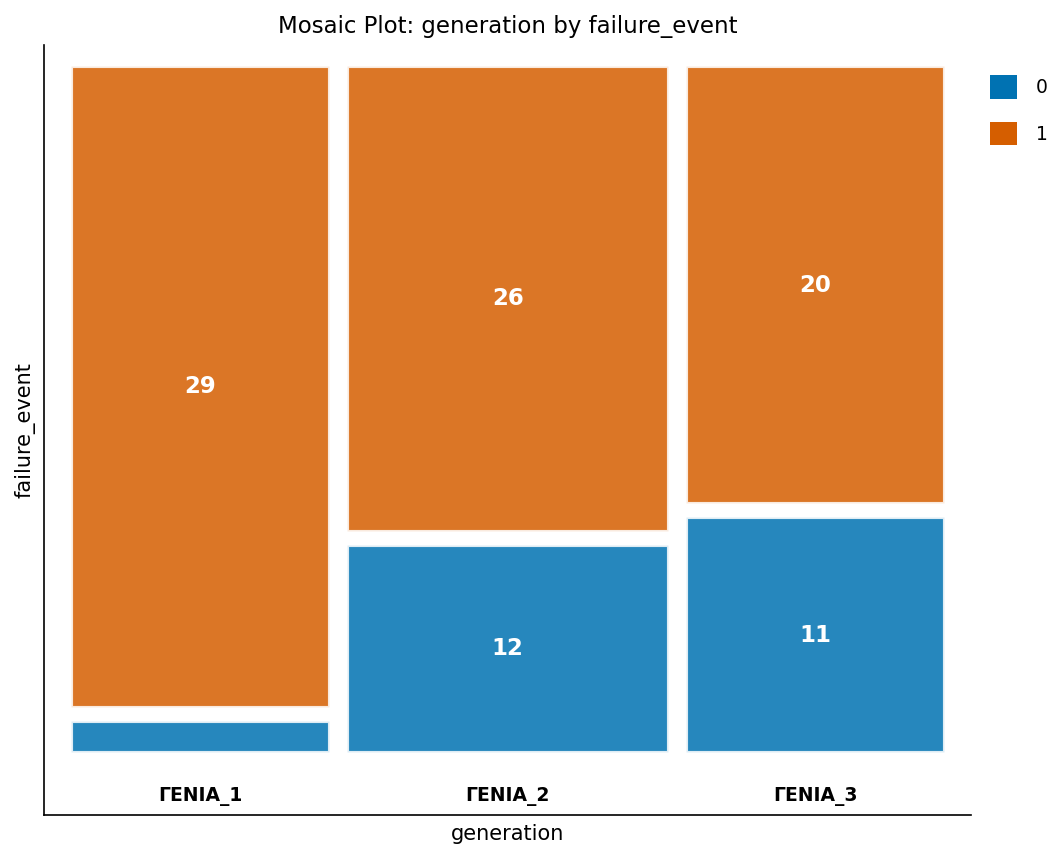

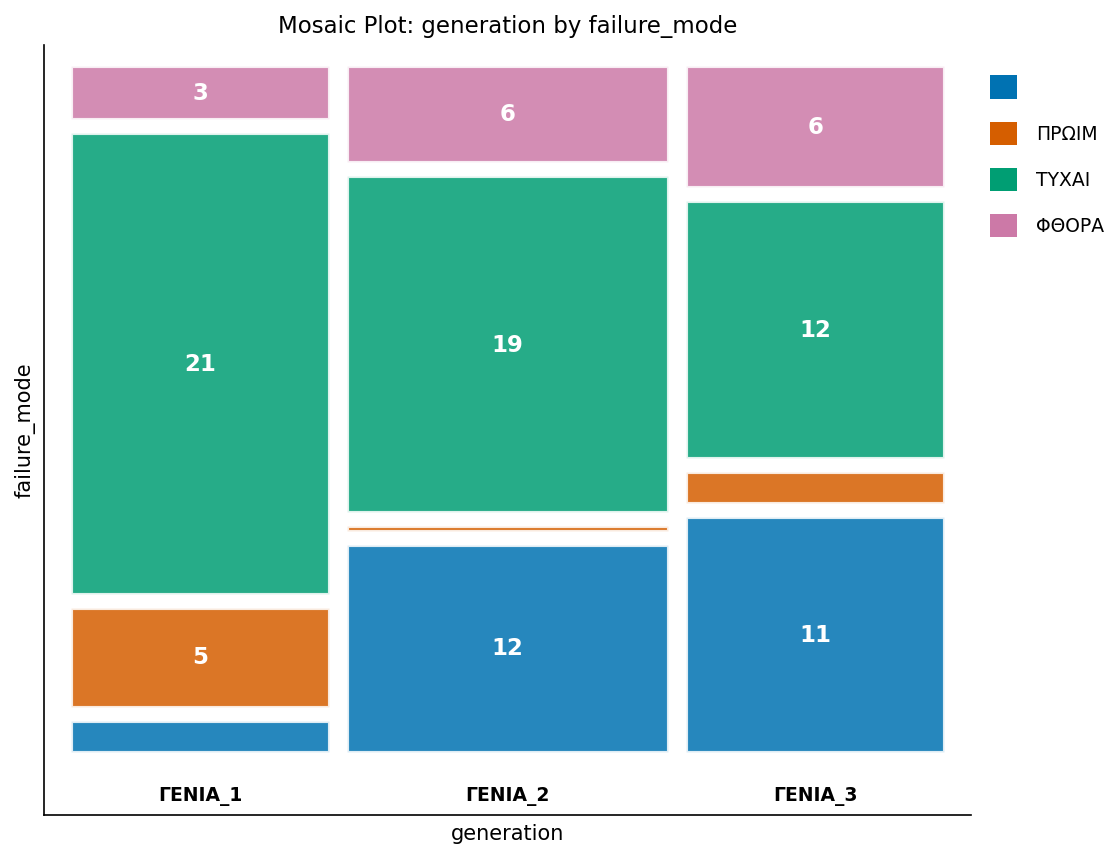

In [2]:
/* --------------------------------------------------------
   Βασικά πλήθη εξοπλισμού και ώρες λειτουργίας ανά γενιά
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.equipment_life;
    ΕΤΙΚΕΤΑ generation='Γενιά' failure_event='Συμβάν Αστοχίας' failure_mode='Τρόπος Αστοχίας';
    TABLES generation * failure_event / nocol nopercent;
    TABLES generation * failure_mode / nocol norow;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.equipment_life n mean std;
    ΕΤΙΚΕΤΑ generation='Γενιά' operating_hours='Ώρες Λειτουργίας';
    ΚΛΑΣΗ generation;
    ΜΕΤΑΒΛΗΤΗ operating_hours;
ΕΚΤΕΛΕΣΗ;

---


NOTE: PROC SGPLOT data=work.equipment_life

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


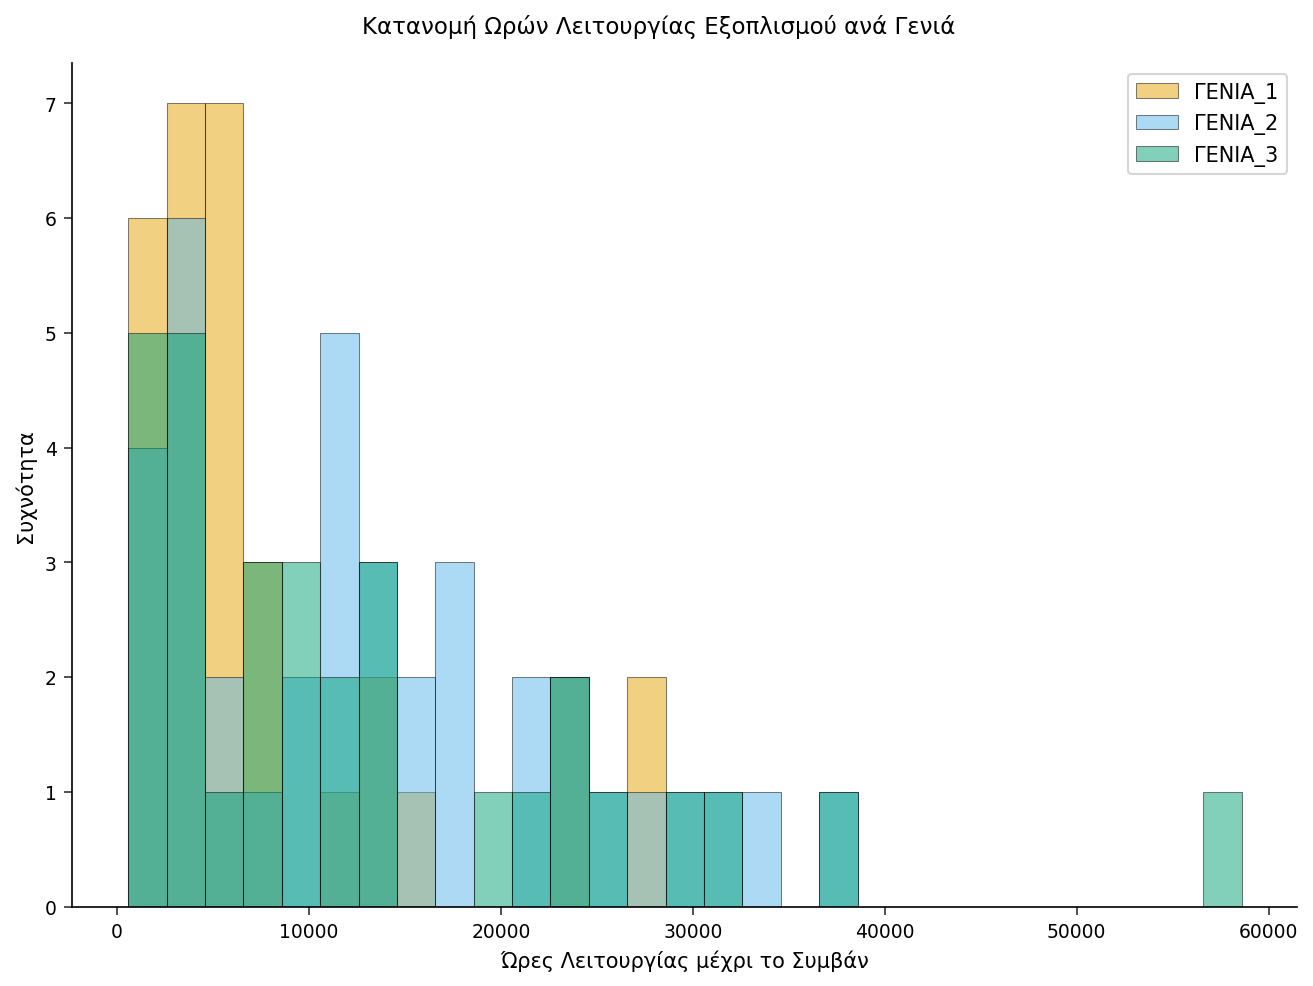

In [3]:
/* --------------------------------------------------------
   Κατανομή ωρών λειτουργίας ανά γενιά
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.equipment_life;
    HISTOGRAM operating_hours / GROUP=generation TRANSPARENCY=0.3 BINWIDTH=2000;
    XAXIS ΕΤΙΚΕΤΑ='Ώρες Λειτουργίας μέχρι το Συμβάν';
    YAXIS ΕΤΙΚΕΤΑ='Συχνότητα';
    TITLE 'Κατανομή Ωρών Λειτουργίας Εξοπλισμού ανά Γενιά';
ΕΚΤΕΛΕΣΗ;

---

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

Stratum: Γενιά = ΓΕΝΙΑ_1

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065     0


NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: OUTSURV dataset 'work.equip_cumhaz' written to: ./work/fba398a2-5f9d-4b90-8b9c-38a8fd0c919d/equip_cumhaz.avro
NOTE: ODS plot written: lifetest_hazard.spec.json
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


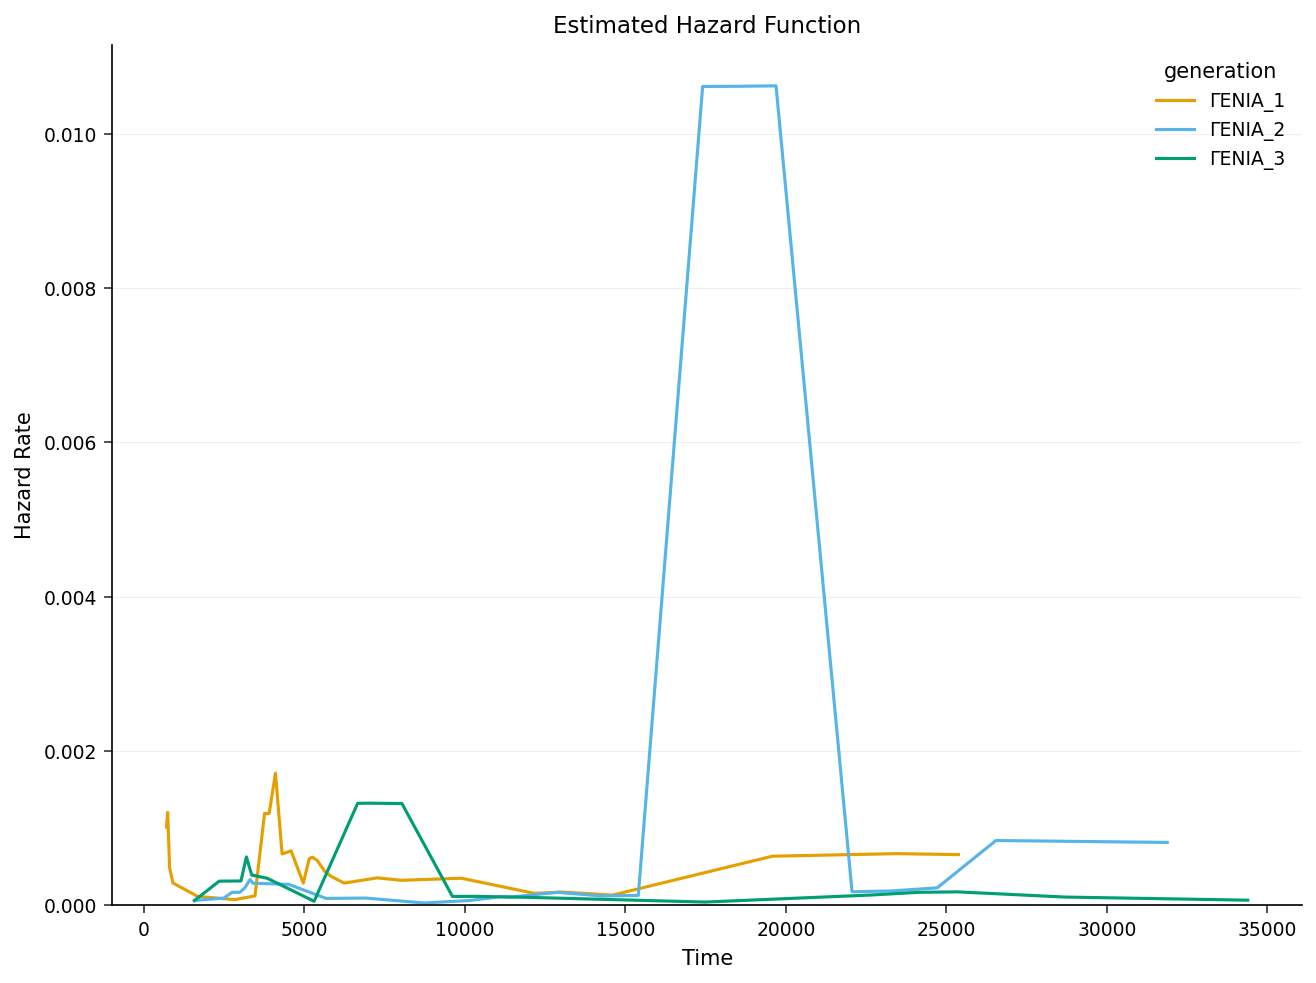

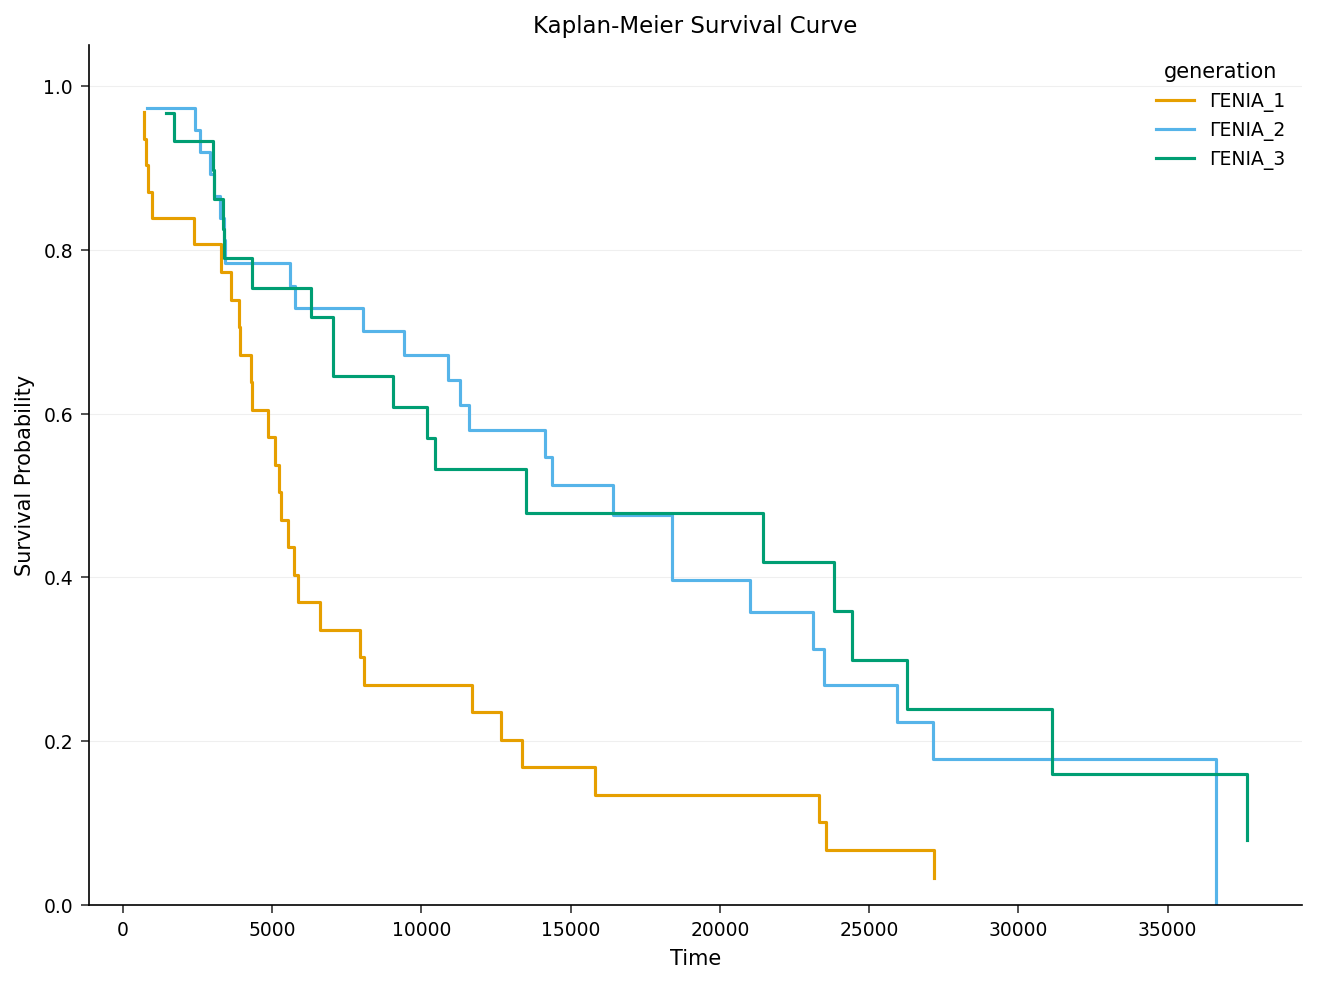

In [4]:
/* --------------------------------------------------------
   Εκτίμηση επιβίωσης Kaplan-Meier ανά γενιά, με την επιλογή
   αθροιστικού κινδύνου Nelson-Aalen για την προβολή κινδύνου.

   STRATA generation / TEST=(LOGRANK WILCOXON) εκτελεί τόσο τον
   έλεγχο log-rank (ευαίσθητο σε διαφορές σε όλο τον χρόνο
   υπηρεσίας) όσο και τον έλεγχο Gehan-Breslow-Wilcoxon (που δίνει
   μεγαλύτερο βάρος στις πρώιμες αστοχίες) στις τρεις γενιές.

   PLOTS=(SURVIVAL HAZARD) σχεδιάζει τις καμπύλες επιβίωσης
   Kaplan-Meier και την πυρηνικά-εξομαλυμένη συνάρτηση κινδύνου.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ LIFETEST ΔΕΔΟΜΕΝΑ=work.equipment_life
    METHOD=km
    nelson
    PLOTS=(SURVIVAL hazard)
    outsurv=work.equip_cumhaz;
    ΕΤΙΚΕΤΑ generation='Γενιά' operating_hours='Ώρες Λειτουργίας';
    TIME operating_hours * failure_event(0);
    STRATA generation / TEST=(logrank WILCOXON);
ΕΚΤΕΛΕΣΗ;

In [5]:
/* --------------------------------------------------------
   Πιθανότητα επιβίωσης σε ορόσημα ωρών λειτουργίας
   (5.000 / 10.000 / 20.000 / 30.000 ώρες) για κάθε γενιά,
   διαβασμένη από τον πίνακα ODS Kaplan-Meier.
   -------------------------------------------------------- */
ODS ΕΞΟΔΟΣ productlimitestimates=work.equip_km_detail;

ΔΙΑΔΙΚΑΣΙΑ LIFETEST ΔΕΔΟΜΕΝΑ=work.equipment_life METHOD=km;
    TIME operating_hours * failure_event(0);
    STRATA generation;
ΕΚΤΕΛΕΣΗ;

ODS ΕΞΟΔΟΣ CLOSE;

/* Ο πίνακας ProductLimitEstimates φέρει μία γραμμή ανά διακριτό
   χρόνο εντός κάθε γενιάς. Για κάθε ορόσημο κρατάμε την πρώτη
   γραμμή της οποίας ο χρόνος είναι στο ή πέρα από αυτό -- δηλαδή
   την εκτίμηση επιβίωσης που ισχύει σε εκείνη την ώρα λειτουργίας. */
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=work.equip_km_detail;
    ΚΑΤΑ generation operating_hours;
ΕΚΤΕΛΕΣΗ;

ΔΕΔΟΜΕΝΑ work.equip_milestones;
    ΟΡΙΣΜΟΣ work.equip_km_detail;
    ΚΑΤΑ generation;
    RETAIN hit5 hit10 hit20 hit30;
    ΕΑΝ first.generation ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
        hit5 = 0; hit10 = 0; hit20 = 0; hit30 = 0;
    ΤΕΛΟΣ;
    LENGTH milestone 8;
    milestone = .;
    ΕΑΝ      operating_hours >= 5000  AND hit5  = 0 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; milestone = 5000;  hit5  = 1; ΤΕΛΟΣ;
    ΑΛΛΙΩΣ ΕΑΝ operating_hours >= 10000 AND hit10 = 0 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; milestone = 10000; hit10 = 1; ΤΕΛΟΣ;
    ΑΛΛΙΩΣ ΕΑΝ operating_hours >= 20000 AND hit20 = 0 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; milestone = 20000; hit20 = 1; ΤΕΛΟΣ;
    ΑΛΛΙΩΣ ΕΑΝ operating_hours >= 30000 AND hit30 = 0 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; milestone = 30000; hit30 = 1; ΤΕΛΟΣ;
    ΕΑΝ milestone ne .;
    ΚΡΑΤΗΣΗ generation milestone operating_hours SURVIVAL sdf_stderr;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.equip_milestones noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ generation     = 'Γενιά'
          milestone       = 'Ορόσημο (ώρες)'
          operating_hours = 'Χρόνος Εκτίμησης'
          SURVIVAL        = 'Πιθανότητα Επιβίωσης'
          sdf_stderr      = 'Τυπικό Σφάλμα';
    ΜΟΡΦΗ SURVIVAL sdf_stderr 6.4;
    TITLE 'Πιθανότητα Επιβίωσης σε Ορόσημα Ωρών Λειτουργίας ανά Γενιά';
ΕΚΤΕΛΕΣΗ;

    The LIFETEST Procedure     

                              N
--------------------  ---------
Total                       100
Event                        75
Censored                     25
Median Survival Time  8438.5000

Stratum: generation = ΓΕΝΙΑ_1

                              N
--------------------  ---------
Total                        31
Event                        29
Censored                      2
Median Survival Time  5282.0000

                Product-Limit Survival Estimates                 

      Time  Survival  Std Error  Number at Risk  Number of Events
----------  --------  ---------  --------------  ----------------
  698.0000    0.9677     0.0317              31                 1
  712.0000    0.9355     0.0441              30                 1
  769.0000    0.9032     0.0531              29                 1
  833.0000    0.8710     0.0602              28                 1
  977.0000    0.8387     0.0661              27                 1
 2368.0000    0.8065 


NOTE: ODS OUTPUT: PRODUCTLIMITESTIMATES -> equip_km_detail
NOTE: PROC LIFETEST data=work.equipment_life

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS OUTPUT: ProductLimitEstimates written to 'equip_km_detail'.
NOTE: PROC LIFETEST completed.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: PROC SORT data=work.equip_km_detail

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_km_detail (75 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.equip_milestones


NOTE: Read 75 rows from work.equip_km_detail.
NOTE: Wrote work.equip_milestones (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=work.equip_milestones

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


---

### Ερμηνεία

Οι καμπύλες επιβίωσης Kaplan-Meier διαχωρίζουν τον στόλο σε δύο σαφή
επίπεδα. Οι αρχικές μηχανές **ΓΕΝΙΑ_1** αστοχούν πιο γρήγορα: η καμπύλη
τους πέφτει κάτω από το 0,5 στις **5.282 ώρες λειτουργίας** (διάμεσος
χρόνος ζωής υπηρεσίας), και μέχρι τις 10.000 ώρες μόνο περίπου **24%**
είναι ακόμη σε λειτουργία. Οι ανασχεδιασμένες μηχανές **ΓΕΝΙΑ_2** και
**ΓΕΝΙΑ_3** επιβιώνουν πολύ περισσότερο -- διάμεσοι χρόνοι ζωής **16.430**
και **13.512** ωρών αντίστοιχα -- και οι καμπύλες επιβίωσής τους βρίσκονται
κοντά η μία στην άλλη σε όλο το παρατηρούμενο εύρος. Στα ορόσημα των
5.000 / 10.000 / 20.000 ωρών οι εκτιμώμενες πιθανότητες επιβίωσης είναι:

| Γενιά | 5.000 ώ | 10.000 ώ | 20.000 ώ |
|------------|--------:|---------:|---------:|
| ΓΕΝΙΑ_1 | 0,54 | 0,24 | 0,10 |
| ΓΕΝΙΑ_2 | 0,76 | 0,64 | 0,36 |
| ΓΕΝΙΑ_3 | 0,72 | 0,57 | 0,42 |

Και οι δύο έλεγχοι ισότητας στρωμάτων απορρίπτουν τη μηδενική υπόθεση ότι
οι τρεις γενιές μοιράζονται μία κατανομή επιβίωσης: ο έλεγχος
**log-rank** δίνει χι-τετράγωνο **12,92** (2 βαθμοί ελευθερίας, *p* =
**0,0016**) και ο έλεγχος **Gehan-Breslow-Wilcoxon** δίνει χι-τετράγωνο
**11,88** (2 βαθμοί ελευθερίας, *p* = **0,0026**). Οι δύο έλεγχοι
συμφωνούν στενά, οπότε η διαφορά οφείλεται στο μεγαλύτερο μέρος του χρόνου
ζωής υπηρεσίας και όχι μόνο στην περιοχή πρώιμων αστοχιών (ο έλεγχος
Wilcoxon δίνει μεγαλύτερο βάρος στα πρώιμα συμβάντα).

Είναι σημαντικό αυτό να διαβαστεί ως βελτίωση **ενός βήματος**, όχι ως
μονοτονικό κέρδος γενιά-προς-γενιά. Η ΓΕΝΙΑ_2 και η ΓΕΝΙΑ_3 είναι
στατιστικά μη διακριτές εδώ -- οι καμπύλες τους επικαλύπτονται και ο
διάμεσος της ΓΕΝΙΑ_2 είναι ονομαστικά ο υψηλότερος από τους δύο -- οπότε
σε αυτό το δείγμα 100 μηχανών δεν υπάρχει απόδειξη ότι η ΓΕΝΙΑ_3 βελτίωσε
τη ΓΕΝΙΑ_2. Το πραγματικό σήμα είναι το μεγάλο, σημαντικό χάσμα μεταξύ
του αρχικού σχεδιασμού ΓΕΝΙΑ_1 και των δύο μεταγενέστερων σχεδιασμών.

Η επιλογή αθροιστικού κινδύνου Nelson-Aalen οδηγεί το συνοδευτικό
διάγραμμα κινδύνου. Σε αυτό το μέγεθος δείγματος ο πυρηνικά-εξομαλυμένος
κίνδυνος είναι θορυβώδης -- η ψηλή αιχμή της ΓΕΝΙΑ_2 κοντά στις 18.000
ώρες αντανακλά ένα μεμονωμένο συμβάν σε ένα μικρό εναπομείναν σύνολο
κινδύνου παρά μια γνήσια έξαρση φθοράς -- οπότε η προβολή κινδύνου θα
πρέπει να αντιμετωπίζεται ποιοτικά· οι καμπύλες επιβίωσης και οι επίσημοι
έλεγχοι φέρουν τα ποσοτικά συμπεράσματα.

**Σύσταση.** Δώστε προτεραιότητα στην αντικατάσταση και στην πιο σφιχτή
επιθεώρηση των εναπομεινάντων μηχανών ΓΕΝΙΑ_1, των οποίων η αξιοπιστία
είναι ουσιωδώς χειρότερη από τον υπόλοιπο στόλο. Αντιμετωπίστε τη ΓΕΝΙΑ_2
και τη ΓΕΝΙΑ_3 ως μία ενιαία, πιο αξιόπιστη ομάδα για τον σχεδιασμό
συντήρησης μέχρι ένα μεγαλύτερο δείγμα να μπορέσει να επιλύσει τυχόν
διαφορά μεταξύ τους.

---

In [6]:
/* --------------------------------------------------------
   Εξαγωγή των δεδομένων αθροιστικού κινδύνου / καμπύλης επιβίωσης
   και του πίνακα επιβίωσης οροσήμων για ένα επόμενο dashboard
   αξιοπιστίας.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.equip_cumhaz
    OUTFILE='equipment_cumulative_hazard.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.equip_milestones
    OUTFILE='equipment_milestone_survival.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.equip_cumhaz outfile=equipment_cumulative_hazard.csv

NOTE: Exported 75 rows to equipment_cumulative_hazard.csv.
NOTE: PROC EXPORT data=work.equip_milestones outfile=equipment_milestone_survival.csv

NOTE: Exported 11 rows to equipment_milestone_survival.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την τεχνολογία <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>